# 능동형 데이터 분석 with AI (실행:ChatGPT 무료)

---
**프롬프트:** 데이터는 `DieCasting_Raw_Data.csv`에 있습니다. pandas로 불러와 `df`에 저장하고, 데이터 크기와 처음 5행을 확인하는 코드를 작성하세요.

In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('DieCasting_Raw_Data.csv')

# 데이터 크기 확인
print("Shape:", df.shape)

# 처음 5행 확인
print(df.head())

Shape: (5161, 17)
   Shot  Velocity_1  Velocity_2  Velocity_3  High_Velocity  Cylinder_Pressure  \
0     1       0.144       0.170       0.188          2.134              214.0   
1     2       0.144       0.170       0.182          2.124              217.0   
2     3       0.144       0.170       0.182          2.116              214.0   
3     4       0.144       0.170       0.182          2.137              217.0   
4     5       0.144       0.172       0.176          2.111              217.0   

   Rapid_Rise_Time  Biscuit_Thickness  Clamping_Force  Cycle_Time  \
0            0.008               10.0           258.0        20.7   
1            0.008               11.0           257.0        20.7   
2            0.008               11.0           257.0        20.8   
3            0.008               11.0           257.0        20.7   
4            0.008               12.0           257.0        20.7   

   Pressure_Rise_Time  Casting_Pressure  Spray_Time  Spray_1_Time  \
0          

**해석:** 
데이터는 총 5,161행, 17개 변수로 구성되어 있고 공정 조건 + 결과 로그 형태입니다. Shot과 _id는 식별자 역할이라 분석 변수에서는 제외하는 게 맞습니다.

Velocity 계열(1~3, High_Velocity), 압력(Cylinder, Casting), 시간(Time 계열), 두께(Biscuit) 등 전형적인 다이캐스팅 공정 파라미터들이 포함되어 있어서 공정-품질 관계 분석에 적합한 구조입니다.

초기 5행 기준으로 보면 값의 변동폭이 크지 않습니다. 특히 Velocity_1, Rapid_Rise_Time, Spray_Time 등은 거의 고정값처럼 보이기 때문에 정보량이 낮을 가능성이 있습니다.

Machine_Status가 0.0으로 보이는데, 이 컬럼이 불량/정상 같은 타겟 변수라면 현재 샘플에서는 단일 클래스만 보입니다. 전체 데이터에서 분포 확인이 반드시 필요합니다.

전반적으로 센서 로그 기반의 정상 공정 데이터 느낌이 강하고, 일부 변수는 변별력이 낮거나 상수에 가까울 가능성이 있어 변수 선택이 중요해 보입니다.

다음 단계로는 각 변수의 분포와 고유값 개수부터 확인하는 게 가장 효율적입니다.

---
**프롬프트:** `df`에 대해 각 컬럼의 데이터 타입과 결측치 수를 확인하세요. `Machine_Status`의 정상/비정상/결측 분포도 표로 출력하세요.

In [2]:
# 데이터 타입 확인
print(df.dtypes)

print("\n결측치 개수:")
print(df.isnull().sum())


# Machine_Status 분포 (정상/비정상/결측 포함)
status_counts = df['Machine_Status'].value_counts(dropna=False)

print("\nMachine_Status 분포:")
print(status_counts)


# 보기 좋게 표 형태로 정리
status_table = status_counts.reset_index()
status_table.columns = ['Machine_Status', 'Count']

print("\nMachine_Status 분포 표:")
print(status_table)

Shot                    int64
Velocity_1            float64
Velocity_2            float64
Velocity_3            float64
High_Velocity         float64
Cylinder_Pressure     float64
Rapid_Rise_Time       float64
Biscuit_Thickness     float64
Clamping_Force        float64
Cycle_Time            float64
Pressure_Rise_Time    float64
Casting_Pressure      float64
Spray_Time            float64
Spray_1_Time          float64
Spray_2_Time          float64
Machine_Status        float64
_id                     int64
dtype: object

결측치 개수:
Shot                    0
Velocity_1            410
Velocity_2            409
Velocity_3            409
High_Velocity         409
Cylinder_Pressure     409
Rapid_Rise_Time       409
Biscuit_Thickness     409
Clamping_Force        409
Cycle_Time            409
Pressure_Rise_Time    409
Casting_Pressure      409
Spray_Time            409
Spray_1_Time          409
Spray_2_Time          409
Machine_Status        113
_id                     0
dtype: int64

Machine_Sta

**해석:**
첫째, 결측 패턴이 매우 특징적입니다. 대부분의 공정 변수에서 동일하게 409건 결측이 발생하고 있어 랜덤 결측이 아니라 특정 구간/샷 단위로 통째로 누락된 구조일 가능성이 높습니다.

둘째, 타겟 변수인 Machine_Status는 심각한 클래스 불균형 상태입니다. 정상 4,930건 대비 비정상 118건으로 약 97.7%가 정상이라 모델링 시 그대로 쓰면 편향 문제가 발생합니다.

셋째, Machine_Status 자체에도 113건 결측이 존재합니다. 이 데이터는 지도학습에서는 직접 사용이 어려워 별도 제거 또는 처리 전략이 필요합니다.

---
**프롬프트:** `Machine_Status`가 결측인 행은 타깃을 알 수 없으므로 별도로 제외하고, 분석용 `labeled_df`를 만드세요. 정상과 비정상 비율도 확인하세요.

In [3]:
# Machine_Status 결측 제거
labeled_df = df.dropna(subset=['Machine_Status']).copy()

# 비율 확인
status_ratio = labeled_df['Machine_Status'].value_counts(normalize=True)

print("Shape (labeled_df):", labeled_df.shape)
print("\n정상/비정상 비율:")
print(status_ratio)

Shape (labeled_df): (5048, 17)

정상/비정상 비율:
Machine_Status
0.0    0.976624
1.0    0.023376
Name: proportion, dtype: float64


**해석:** 현재 라벨이 있는 데이터는 5,048건이고, 이 중 약 97.7%가 정상, 2.3%만 비정상입니다. 공정 데이터에서 흔한 패턴이긴 하지만, 그대로 모델링하면 “전부 정상”이라고 예측해도 높은 정확도가 나오는 구조입니다.

즉, 정확도(accuracy)는 거의 의미 없고, 비정상 검출 성능(재현율, precision, F1, 특히 recall)을 중심으로 봐야 합니다. 그렇지 않으면 실제 불량을 거의 못 잡는 모델이 나올 가능성이 큽니다.

또 하나 중요한 점은 비정상 샘플이 약 118건 수준이라 절대량 자체도 적습니다. 이 상태에서는 모델 복잡도를 높이기보다, 데이터 분할 방식과 불균형 처리(가중치, 샘플링)가 성능을 좌우할 가능성이 큽니다.

이 정도면 분석 자체는 충분히 가능하지만, “불량 탐지 문제”로 접근해야 의미 있는 결과가 나옵니다.

---
**프롬프트:** 식별자나 타깃으로 보이는 컬럼을 제외하고 측정값 컬럼 목록을 만들어 주세요. 그 측정값 컬럼들의 기초 통계량을 확인하세요.

In [4]:
# 제외할 컬럼 정의
exclude_cols = ['Shot', '_id', 'Machine_Status']

# 측정값 컬럼 추출
feature_cols = [col for col in labeled_df.columns if col not in exclude_cols]

print("측정값 컬럼 목록:")
print(feature_cols)


# 기초 통계량 확인
print("\n기초 통계량:")
print(labeled_df[feature_cols].describe())

측정값 컬럼 목록:
['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time']

기초 통계량:
        Velocity_1   Velocity_2   Velocity_3  High_Velocity  \
count  4721.000000  4722.000000  4722.000000    4722.000000   
mean      0.147995     0.168656     0.190805       2.301518   
std       0.007054     0.004450     0.011582       0.317231   
min       0.134000     0.158000     0.172000       0.000000   
25%       0.142000     0.166000     0.181000       2.133000   
50%       0.144000     0.168000     0.187000       2.159000   
75%       0.155000     0.170000     0.202000       2.524000   
max       0.180000     0.212000     0.234000       2.744000   

       Cylinder_Pressure  Rapid_Rise_Time  Biscuit_Thickness  Clamping_Force  \
count        4722.000000      4722.000000        4722.000000     4722.000000   
mean       

**해석:** 첫째, 이상치(outlier)가 확실히 존재합니다.
Cycle_Time 최대값이 6170인데, 중앙값이 약 21.6인 걸 보면 완전히 다른 레벨의 값입니다. High_Velocity, Rapid_Rise_Time, Pressure_Rise_Time에서도 최소값이 0인 구간이 보이는데, 공정적으로 불가능하거나 센서/로깅 오류일 가능성이 높습니다. 이런 값들은 그대로 쓰면 모델이 왜곡됩니다.

둘째, 변수별 정보량 차이가 큽니다.
Velocity_2, Rapid_Rise_Time 같은 변수는 분산이 매우 작아서 사실상 거의 고정값에 가깝습니다. 반면 Casting_Pressure, Clamping_Force, Biscuit_Thickness는 분산이 크고 공정 상태 변화를 잘 반영하는 변수로 보입니다. 즉, 모든 변수를 동일하게 쓰는 건 비효율적입니다.

셋째, 데이터 스케일과 분포가 심하게 비정상적입니다.
Cycle_Time처럼 분포가 한쪽으로 크게 치우친 변수(heavy tail)가 있고, 일부 변수는 0 값이 섞여 있어 “정상 공정 vs 비정상/오류 로그”가 혼재된 상태입니다. 이 상태에서는 스케일링보다 먼저 이상치/비정상 값 정리가 선행되어야 합니다.

이 정도면 다음 단계에서 “이상치 제거 기준”을 어떻게 잡느냐가 모델 성능을 크게 좌우할 상황입니다.

---
**프롬프트:** 측정값 컬럼에서 결측이 있는 행과 없는 행을 나누어 보세요. 두 그룹의 비정상 비율을 비교하세요.

In [5]:
# 측정값 컬럼 기준 결측 여부 마스크
has_missing = labeled_df[feature_cols].isnull().any(axis=1)

# 그룹 분리
missing_df = labeled_df[has_missing]
complete_df = labeled_df[~has_missing]

# 각 그룹의 비정상 비율
missing_ratio = missing_df['Machine_Status'].mean()
complete_ratio = complete_df['Machine_Status'].mean()

print("결측 포함 그룹 크기:", missing_df.shape)
print("결측 없는 그룹 크기:", complete_df.shape)

print("\n비정상 비율 비교")
print(f"결측 포함 그룹: {missing_ratio:.4f}")
print(f"결측 없는 그룹: {complete_ratio:.4f}")

결측 포함 그룹 크기: (327, 17)
결측 없는 그룹 크기: (4721, 17)

비정상 비율 비교
결측 포함 그룹: 0.0428
결측 없는 그룹: 0.0220


**해석:**
결측이 있는 그룹에서 비정상 비율이 약 4.28%, 결측이 없는 그룹은 2.20%로 거의 2배 차이가 납니다. 단순한 데이터 누락이 아니라, “문제 상황에서 데이터가 같이 깨지는 패턴”일 가능성이 높습니다.

즉, 이 결측은 MCAR(완전 무작위 결측)가 아니라 공정 이상과 연관된 MNAR 성격으로 보는 게 타당합니다. 실무적으로는 결측 자체가 하나의 이상 징후(feature)가 될 수 있는 상황입니다.

그래서 무작정 결측 제거하거나 평균 대치하는 접근은 정보 손실이 발생할 수 있습니다. 오히려 “결측 여부 indicator 변수”를 추가하거나, 결측 포함 데이터를 유지한 채 모델링하는 전략이 더 유효할 가능성이 큽니다.

이 데이터에서는 “값”뿐 아니라 “값이 없는 것” 자체도 신호로 봐야 합니다.

---
**프롬프트:** 측정값 결측이 한 행에서 몇 개씩 동시에 발생하는지 확인하세요. 결측 개수별 행 수와 비정상 비율을 표로 보여주세요.

In [6]:
# 행별 결측 개수 계산
labeled_df['missing_count'] = labeled_df[feature_cols].isnull().sum(axis=1)

# 결측 개수별 집계
summary = labeled_df.groupby('missing_count').agg(
    row_count=('Machine_Status', 'count'),
    abnormal_ratio=('Machine_Status', 'mean')
).reset_index()

print(summary.sort_values('missing_count'))

   missing_count  row_count  abnormal_ratio
0              0       4721        0.022029
1              1          1        0.000000
2             14        326        0.042945


**해석:** 결측이 1개만 있는 경우는 사실상 의미 없는 수준(1건)이고, 대부분의 결측은 “14개 컬럼이 동시에 결측”인 형태로 발생하고 있습니다. 즉, 개별 센서 문제가 아니라 특정 시점에서 데이터가 통째로 빠진 이벤트성 결측입니다.

그리고 그 구간(14개 결측)의 비정상 비율이 약 4.29%로, 정상 구간(2.2%) 대비 약 2배입니다. 이건 단순 노이즈가 아니라 “공정 이상 또는 장비 상태 변화 시 로그 수집 실패” 같은 구조적 문제일 가능성이 큽니다.

정리하면 이 데이터의 결측은
값이 없는 게 아니라 “특정 상황에서 측정 자체가 안 된 것”이고, 그 상황이 불량과 연결되어 있습니다.

이 단계에서는 결측을 제거하기보다는,
missing_count > 0 같은 이진 변수 하나만 추가해도 꽤 강한 설명력을 가질 가능성이 높습니다.

---
**프롬프트:** 측정값 컬럼들의 분포를 히스토그램으로 확인하세요. 분포가 치우쳤거나 이상치가 커 보이는 변수도 눈으로 볼 수 있게 해주세요.

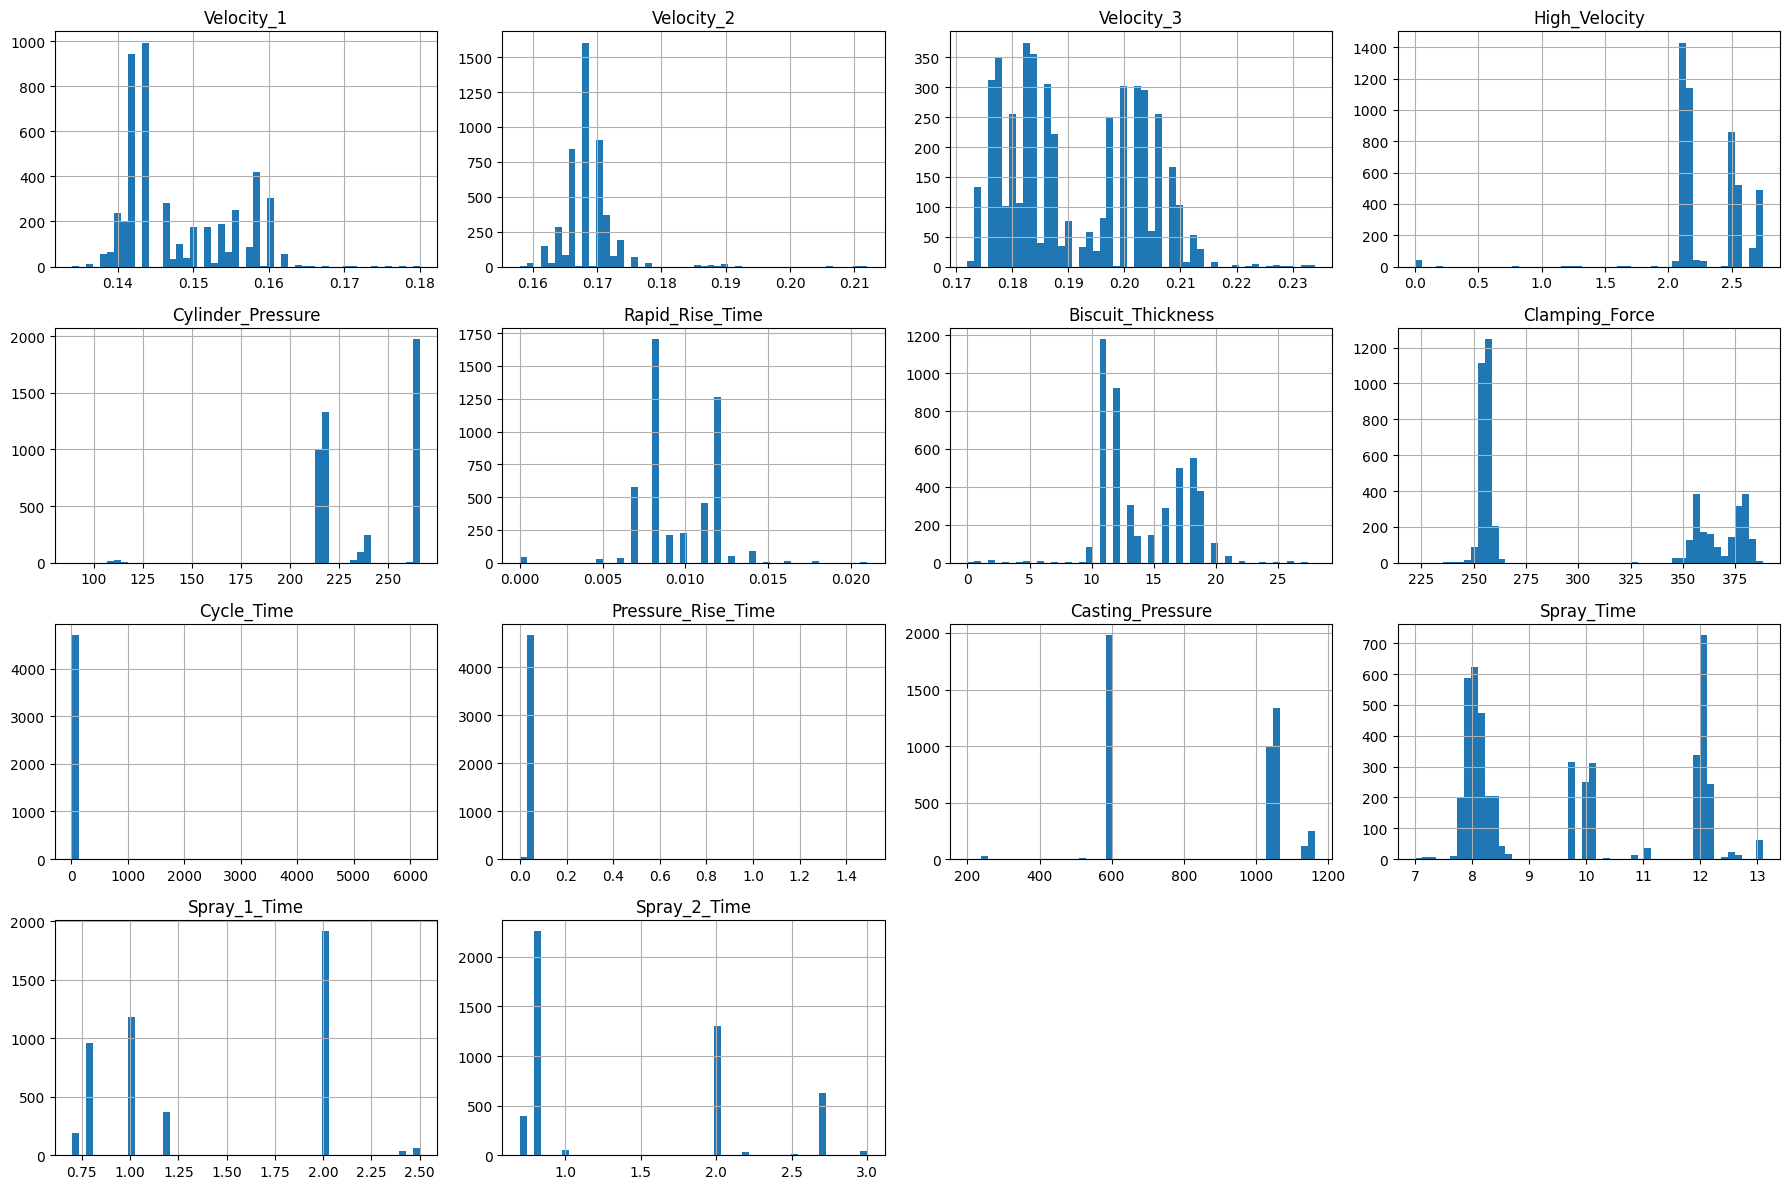

In [7]:
import matplotlib.pyplot as plt

# 히스토그램 그리기
labeled_df[feature_cols].hist(
    bins=50,
    figsize=(18, 12)
)

plt.tight_layout()
plt.show()

**해석:** Cycle_Time, Pressure_Rise_Time는 정상 분포라고 보기 어렵습니다. 대부분 값이 한쪽(낮은 구간)에 몰려 있고, 극단적으로 큰 값이 꼬리처럼 길게 튀어나와 있습니다. 특히 Cycle_Time은 6000대 값이 명확한 이상치라서 그대로 쓰면 모델이 이 값에 과도하게 반응할 가능성이 큽니다.

High_Velocity, Rapid_Rise_Time는 0 근처 값이 존재합니다. 공정적으로 “0”이 의미 있는 값이라기보다 측정 실패나 로그 오류일 가능성이 높습니다. 실제 분포도 보면 정상 구간과 분리된 작은 덩어리로 떨어져 있습니다.

Clamping_Force, Casting_Pressure, Spray_Time 계열은 다봉 분포(multi-modal)가 뚜렷합니다. 이건 공정 조건이 여러 셋업(setpoint)으로 운영되고 있다는 의미라서, 단일 연속 변수라기보다 “운영 상태 그룹”이 숨어 있다고 보는 게 맞습니다.

Velocity 계열은 전반적으로 분산이 작고 일부는 계단형(이산값 느낌) 분포입니다. 제어값(setpoint)에 가까운 변수일 가능성이 높고, 미세 변화보다는 특정 구간 구분이 더 중요할 수 있습니다.

정리하면 지금 상태는
“이상치 + 0값 노이즈 + 다중 공정 모드”가 섞인 전형적인 제조 데이터 구조입니다.
이걸 그대로 모델에 넣기보다는 이상치 처리와 구간화(혹은 클러스터링) 방향이 핵심이 될 상황입니다.

---
**프롬프트:** 히스토그램만으로는 이상치를 판단하기 어려우니, 측정값 컬럼별 왜도, 99% 분위수, 최댓값을 표로 정리하세요.

In [8]:
import pandas as pd

# 왜도, 99% 분위수, 최댓값 계산
summary_stats = pd.DataFrame({
    'skewness': labeled_df[feature_cols].skew(),
    'q99': labeled_df[feature_cols].quantile(0.99),
    'max': labeled_df[feature_cols].max()
})

# 보기 좋게 정렬 (왜도 기준)
summary_stats = summary_stats.sort_values(by='skewness', ascending=False)

print(summary_stats)

                     skewness       q99       max
Pressure_Rise_Time  47.196568     0.044     1.490
Cycle_Time          36.046216    37.000  6170.000
Velocity_2           3.987948     0.188     0.212
Velocity_1           0.665685     0.162     0.180
Spray_2_Time         0.567096     2.700     3.000
Spray_Time           0.439434    13.000    13.100
Clamping_Force       0.338023   382.000   388.000
Velocity_3           0.331789     0.214     0.234
Spray_1_Time         0.230455     2.500     2.500
Biscuit_Thickness    0.148015    21.000    28.000
Rapid_Rise_Time     -0.099493     0.014     0.021
Casting_Pressure    -0.295179  1158.000  1164.000
Cylinder_Pressure   -0.836592   265.000   266.000
High_Velocity       -3.253806     2.724     2.744


**해석:** 
* Cycle_Time과 Pressure_Rise_Time은 q99 대비 max가 지나치게 커서 **명확한 이상치(로그/센서 오류 가능성)**로 판단됨
* Velocity_2는 왜도가 크지만 극단값이라기보다 **우측으로 치우친 분포**로 변환 대상임
* 대부분 변수는 왜도 ±1 범위로 **안정적인 공정 데이터**로 볼 수 있음
* High_Velocity는 값이 상한에 몰린 **제어/세팅 기반 변수 특성**을 보임
* 전체적으로 **정상 데이터 + 이상 이벤트 데이터가 혼재된 구조**이며, 이상치 처리가 핵심임


---

**프롬프트:** 정상과 비정상 그룹에서 측정값 컬럼의 평균과 중앙값을 비교하세요. 변수 단위 차이를 고려해 표준화된 차이도 함께 계산해 주세요.

In [9]:
import pandas as pd
import numpy as np

# 그룹 분리
normal_df = labeled_df[labeled_df['Machine_Status'] == 0]
abnormal_df = labeled_df[labeled_df['Machine_Status'] == 1]

# 평균 / 중앙값
mean_normal = normal_df[feature_cols].mean()
mean_abnormal = abnormal_df[feature_cols].mean()

median_normal = normal_df[feature_cols].median()
median_abnormal = abnormal_df[feature_cols].median()

# 표준편차 (전체 기준)
std_all = labeled_df[feature_cols].std()

# 표준화된 차이 (effect size)
std_diff = (mean_abnormal - mean_normal) / std_all

# 결과 테이블
comparison_df = pd.DataFrame({
    'mean_normal': mean_normal,
    'mean_abnormal': mean_abnormal,
    'median_normal': median_normal,
    'median_abnormal': median_abnormal,
    'std_diff': std_diff
})

# 영향 큰 변수부터 정렬
comparison_df = comparison_df.reindex(
    comparison_df['std_diff'].abs().sort_values(ascending=False).index
)

print(comparison_df)

                    mean_normal  mean_abnormal  median_normal  \
High_Velocity          2.323073       1.344404          2.160   
Cylinder_Pressure    238.485492     186.355769        234.000   
Cycle_Time            27.354612     251.154808         21.400   
Rapid_Rise_Time        0.009594       0.005548          0.008   
Casting_Pressure     862.578822     669.971154       1037.000   
Biscuit_Thickness     14.153097      15.442308         13.000   
Spray_Time             9.646189      10.222115          8.500   
Pressure_Rise_Time     0.039807       0.047173          0.041   
Spray_1_Time           1.396535       1.517308          1.200   
Velocity_2             0.168639       0.169404          0.168   
Spray_2_Time           1.407731       1.519231          0.800   
Velocity_1             0.147974       0.148913          0.144   
Velocity_3             0.190778       0.192010          0.187   
Clamping_Force       303.787137     304.884615        258.000   

                    medi

**해석:**
High_Velocity, Cylinder_Pressure는 비정상에서 크게 낮아지고 있습니다. 표준화 차이가 각각 -3.08, -1.99 수준이라 단순 상관이 아니라 거의 핵심 분리 변수입니다. 특히 High_Velocity는 영향력이 압도적입니다.

Cycle_Time은 반대로 비정상에서 크게 증가합니다. 다만 앞에서 확인한 극단 이상치 영향이 섞여 있어서, 이 변수는 정제 이후 재평가가 필요한 변수입니다.

Rapid_Rise_Time도 의미 있게 감소(-1.72)합니다. 압력/속도 상승 관련 변수들이 전반적으로 “비정상 시 반응이 둔해지는 패턴”을 보입니다.

Casting_Pressure는 평균은 낮아지지만, 중앙값 차이가 더 큽니다. 이건 분포 왜곡(이상치 영향)이 있다는 신호라서 median 기반 해석이 더 신뢰도 높습니다.

나머지 변수들은 std_diff가 0.3 이하라 영향력이 제한적입니다. 즉, 이 문제는 많은 변수 쓰는 것보다
소수 핵심 변수(속도, 압력, 상승시간) 중심으로 접근하는 게 훨씬 효율적인 구조입니다.

---
**프롬프트:** 앞에서 차이가 커 보이는 변수 몇 개를 골라 정상/비정상별 박스플롯으로 비교하세요.

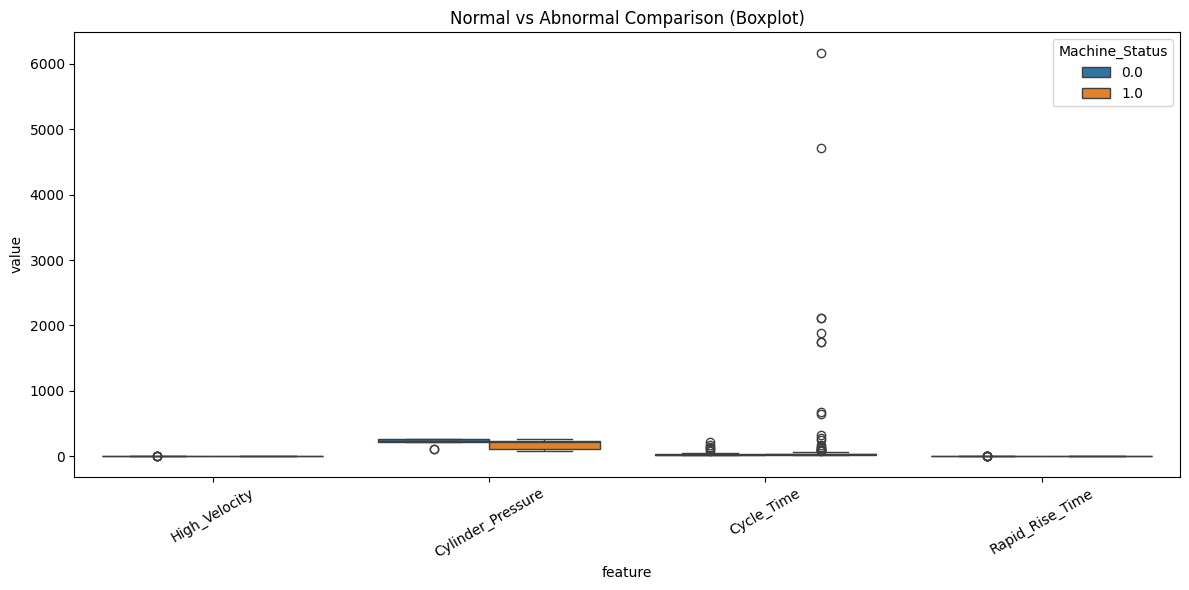

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 비교할 주요 변수 선택
key_cols = [
    'High_Velocity',
    'Cylinder_Pressure',
    'Cycle_Time',
    'Rapid_Rise_Time'
]

# long format 변환
plot_df = labeled_df[['Machine_Status'] + key_cols].melt(
    id_vars='Machine_Status',
    var_name='feature',
    value_name='value'
)

# 박스플롯
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='feature', y='value', hue='Machine_Status')

plt.xticks(rotation=30)
plt.title('Normal vs Abnormal Comparison (Boxplot)')
plt.tight_layout()
plt.show()

> 세로축 스케일 문제로 그림을 별도로 다시 그려달라고 추가 요청

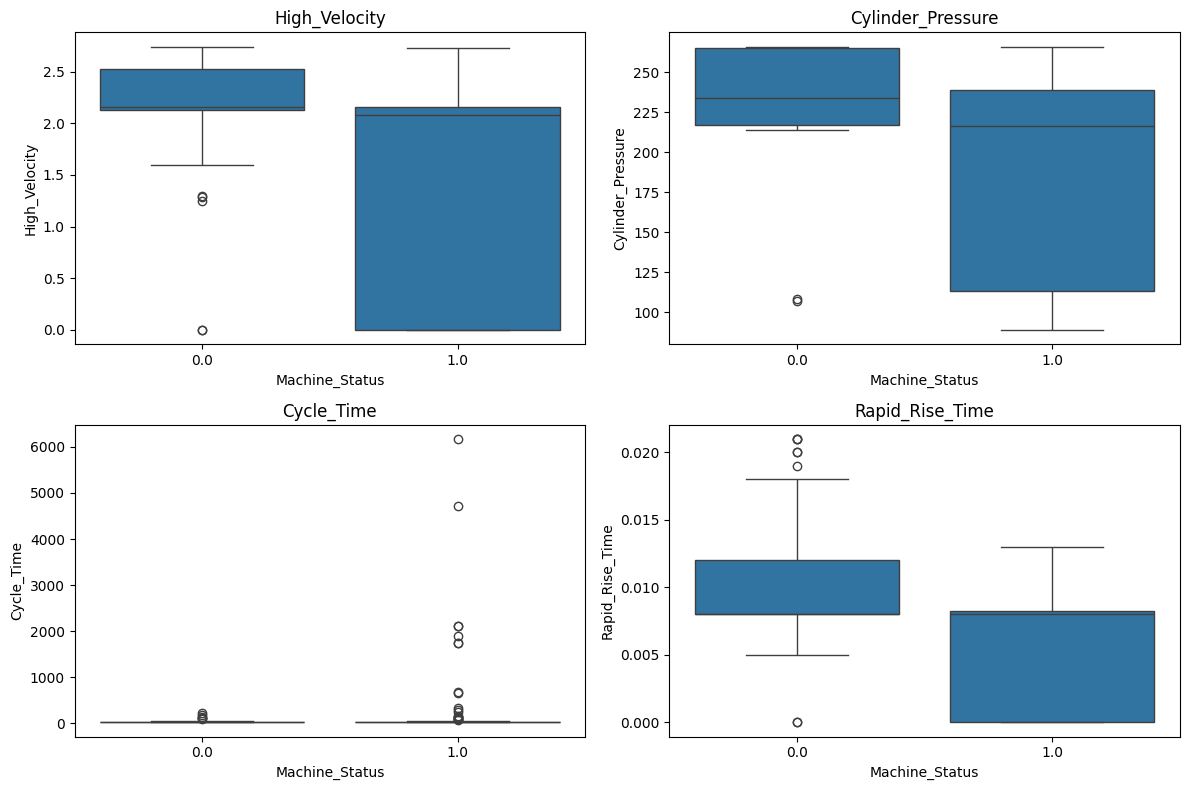

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 주요 변수
key_cols = [
    'High_Velocity',
    'Cylinder_Pressure',
    'Cycle_Time',
    'Rapid_Rise_Time'
]

# subplot 구성
n_cols = 2
n_rows = math.ceil(len(key_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

# 변수별 박스플롯
for i, col in enumerate(key_cols):
    sns.boxplot(
        data=labeled_df,
        x='Machine_Status',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)

# 빈 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**해석:**
High_Velocity는 비정상에서 값이 크게 낮아지면서 분포가 아래로 무너집니다. 특히 0 근처 값이 비정상에 집중된 점이 강력한 신호입니다. 단일 변수로도 분류력이 있는 수준입니다.

Cylinder_Pressure도 비정상에서 전반적으로 낮은 구간으로 이동합니다. 분포 겹침은 있지만 중앙값 자체가 내려가 있어 안정적인 설명 변수입니다.

Cycle_Time은 다시 봐도 해석 대상이 아니라 “이상 이벤트 탐지 변수”입니다. 비정상에서 극단값이 집중되는데, 이건 공정 특성이라기보다 로그 이상 신호로 보는 게 맞습니다.

Rapid_Rise_Time은 비정상에서 낮아지는 경향이 있지만, 분포 겹침이 있어 단독보다는 보조 변수입니다. 다만 0값이 비정상 쪽에 더 많이 나타나는 패턴은 의미 있습니다.

정리하면 지금 단계에서는
High_Velocity → 1순위 핵심 변수
Cylinder_Pressure → 2순위 핵심 변수
Rapid_Rise_Time → 보조 변수
Cycle_Time → 정제 후 조건부 사용

---
**프롬프트**: 앞에서 고른 후보 변수들을 구간으로 나누어 구간별 비정상 비율을 확인하세요.

In [12]:
import pandas as pd

# 사용할 변수
key_cols = [
    'High_Velocity',
    'Cylinder_Pressure',
    'Rapid_Rise_Time'
]

# 결과 저장용
bin_results = {}

for col in key_cols:
    # 분위 기반 구간 나누기 (qcut)
    labeled_df[f'{col}_bin'] = pd.qcut(
        labeled_df[col],
        q=5,
        duplicates='drop'
    )
    
    # 구간별 비정상 비율
    summary = labeled_df.groupby(f'{col}_bin')['Machine_Status'].agg(
        count='count',
        abnormal_ratio='mean'
    ).reset_index()
    
    bin_results[col] = summary
    print(f"\n=== {col} ===")
    print(summary)


=== High_Velocity ===
  High_Velocity_bin  count  abnormal_ratio
0   (-0.001, 2.128]   1006        0.065606
1    (2.128, 2.148]    885        0.006780
2    (2.148, 2.499]    947        0.011616
3    (2.499, 2.529]    948        0.010549
4    (2.529, 2.744]    936        0.011752

=== Cylinder_Pressure ===
  Cylinder_Pressure_bin  count  abnormal_ratio
0       (88.999, 215.0]    993        0.047331
1        (215.0, 218.0]   1343        0.015637
2        (218.0, 264.0]    916        0.028384
3        (264.0, 265.0]   1468        0.006131
4        (265.0, 266.0]      2        0.500000

=== Rapid_Rise_Time ===
  Rapid_Rise_Time_bin  count  abnormal_ratio
0     (-0.001, 0.008]   2394        0.032581
1      (0.008, 0.011]    890        0.014607
2      (0.011, 0.012]   1260        0.008730
3      (0.012, 0.021]    178        0.011236


**해석:**
High_Velocity는 아주 명확합니다.
2.128 이하 구간에서 비정상 비율이 6.5%로, 나머지 구간(약 1% 내외) 대비 압도적으로 높습니다. 사실상 임계값(threshold)이 존재한다고 봐도 됩니다.
→ “High_Velocity 낮음 = 위험” 구조가 확정적입니다.

Cylinder_Pressure도 유사한 패턴입니다.
215 이하에서 4.7%로 튀고, 264~265 구간은 오히려 가장 안정적입니다.
→ 압력이 낮은 구간이 위험, 일정 수준 이상에서는 안정화되는 비선형 구조입니다.

Rapid_Rise_Time은 상대적으로 약하지만 방향성은 있습니다.
0.008 이하에서 비정상 비율이 가장 높고, 값이 커질수록 감소합니다.
→ 완만한 threshold는 있지만, 단독 기준으로 쓰기엔 신호가 약합니다.

정리하면 지금 데이터는 복잡한 모델 없이도

“High_Velocity ↓ + Cylinder_Pressure ↓ → 불량 확률 급증”

---
**프롬프트:** 구간별 비정상 비율을 바탕으로 분위수 기준의 단일 룰 후보를 여러 개 시험해 보세요. 성능은 accuracy, precision, recall, f1로 비교하세요.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# 타겟
y_true = labeled_df['Machine_Status']

# 후보 룰 정의 (분위수 기반)
rules = {
    "HV_low": labeled_df['High_Velocity'] <= labeled_df['High_Velocity'].quantile(0.2),
    "CP_low": labeled_df['Cylinder_Pressure'] <= labeled_df['Cylinder_Pressure'].quantile(0.2),
    "RRT_low": labeled_df['Rapid_Rise_Time'] <= labeled_df['Rapid_Rise_Time'].quantile(0.2),
    
    # 조합 룰
    "HV_low & CP_low": (
        (labeled_df['High_Velocity'] <= labeled_df['High_Velocity'].quantile(0.2)) &
        (labeled_df['Cylinder_Pressure'] <= labeled_df['Cylinder_Pressure'].quantile(0.2))
    ),
    
    "HV_low & RRT_low": (
        (labeled_df['High_Velocity'] <= labeled_df['High_Velocity'].quantile(0.2)) &
        (labeled_df['Rapid_Rise_Time'] <= labeled_df['Rapid_Rise_Time'].quantile(0.2))
    )
}

# 성능 평가
for name, condition in rules.items():
    y_pred = condition.astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# 결과 정리
import pandas as pd
result_df = pd.DataFrame(results, columns=['rule', 'accuracy', 'precision', 'recall', 'f1'])
print(result_df.sort_values(by='f1', ascending=False))

               rule  accuracy  precision    recall        f1
3   HV_low & CP_low  0.923336   0.118980  0.355932  0.178344
4  HV_low & RRT_low  0.827258   0.073529  0.550847  0.129741
0            HV_low  0.803487   0.065606  0.559322  0.117438
1            CP_low  0.798534   0.047331  0.398305  0.084608
2           RRT_low  0.533281   0.032581  0.661017  0.062102


**해석:** HV_low & CP_low 조합이 가장 균형 잡힌 룰입니다. recall이 0.36 수준이지만 precision이 다른 룰 대비 확실히 높아서, “쓸 수 있는 수준의 경보” 형태입니다. 단순 룰 치고는 f1도 가장 안정적입니다.

HV_low 단일 룰은 recall이 0.56으로 높습니다. 대신 precision이 매우 낮아서 거의 “과검출(오탐 많음)” 상태입니다. 불량을 놓치면 안 되는 상황에서는 의미 있지만, 현장 적용 시 부담이 큽니다.

HV_low & RRT_low는 recall을 더 끌어올리지만 precision이 더 떨어집니다. 즉, 더 많이 잡는 대신 더 많이 틀리는 구조라서 운영 관점에서는 부담이 커집니다.

CP_low, RRT_low 단독은 정보력이 약합니다. 특히 RRT_low는 recall은 높지만 precision이 너무 낮아서 단독 룰로는 부적합합니다.

정리하면 현재 데이터에서는
“High_Velocity가 핵심 축이고, 여기에 Cylinder_Pressure를 붙여서 노이즈를 줄이는 구조”가 가장 합리적입니다.

이건 전형적인 패턴입니다.
단일 강한 변수 + 보조 변수로 필터링 → precision 개선.

지금 단계 기준으로는
간단한 룰만으로도 이미 의미 있는 수준까지 왔고,
이걸 트리 기반 모델로 확장하면 자연스럽게 성능이 더 올라갈 구조입니다.

**프롬프트:** 가장 성능이 좋은 단일 룰을 시각화해 주세요. 해당 변수의 분포와 기준선을 함께 보여주세요.

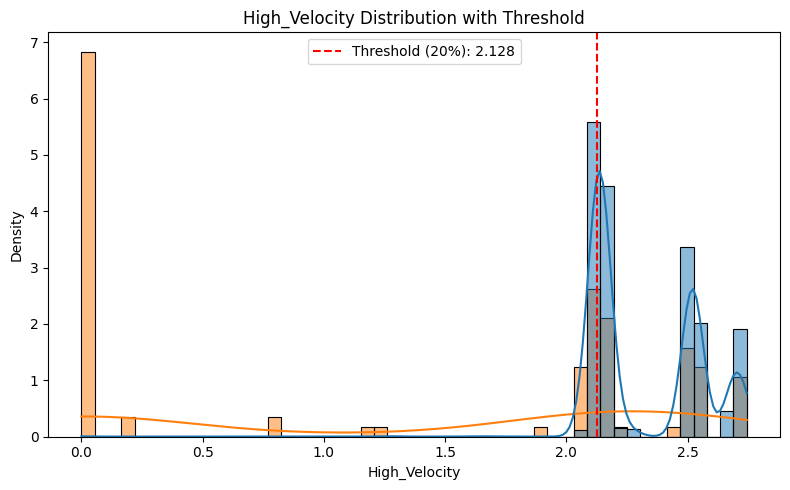

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 기준값 (20% 분위수)
threshold = labeled_df['High_Velocity'].quantile(0.2)

plt.figure(figsize=(8, 5))

# 분포 (정상/비정상 구분)
sns.histplot(
    data=labeled_df,
    x='High_Velocity',
    hue='Machine_Status',
    bins=50,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.5
)

# 기준선 표시
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold (20%): {threshold:.3f}')

plt.title('High_Velocity Distribution with Threshold')
plt.legend()
plt.tight_layout()
plt.show()

**해석:**기준선(2.128) 왼쪽에 비정상이 확실히 몰려 있긴 합니다. 특히 0 근처 값들이 거의 전부 비정상이라서 이 구간은 “강한 불량 신호”입니다.

문제는 그 구간에 정상 데이터도 같이 많이 들어온다는 점입니다. 즉, 분리는 되지만 겹침이 커서 precision이 낮아지는 구조입니다. 지금 recall이 높은 대신 precision이 낮은 이유가 정확히 이 그림입니다.

또 하나 중요한 포인트는 분포가 연속적이지 않고 “두 덩어리(0 근처 vs 2.0 이상)”로 나뉘어 있다는 점입니다. 이건 단순 threshold 문제라기보다
“정상 공정 vs 이상 이벤트(0값)”가 섞인 구조입니다.

정리하면 지금 threshold(20%)는 나쁘지 않지만 최적은 아닙니다.
특히 “0 근처 값”만 따로 분리하면 precision이 크게 올라갈 여지가 있습니다.

즉, 현재 구조는
단일 threshold → 성능 한계 존재
구간 분리(특히 0 영역 분리) → 성능 개선 가능

---
**프롬프트:** 지금까지 만든 룰 중 서로 보완될 만한 것들을 OR 조건으로 결합해 보세요. 혼동행렬과 precision, recall, f1을 확인하세요.

In [15]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = labeled_df['Machine_Status']

# 기존 기준 재사용
hv_low = labeled_df['High_Velocity'] <= labeled_df['High_Velocity'].quantile(0.2)
cp_low = labeled_df['Cylinder_Pressure'] <= labeled_df['Cylinder_Pressure'].quantile(0.2)
rrt_low = labeled_df['Rapid_Rise_Time'] <= labeled_df['Rapid_Rise_Time'].quantile(0.2)

# OR 결합 룰들
or_rules = {
    "HV OR CP": (hv_low | cp_low),
    "HV OR RRT": (hv_low | rrt_low),
    "CP OR RRT": (cp_low | rrt_low),
    "HV OR CP OR RRT": (hv_low | cp_low | rrt_low)
}

# 평가
for name, condition in or_rules.items():
    y_pred = condition.astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n=== {name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")


=== HV OR CP ===
Confusion Matrix:
 [[3355 1575]
 [  47   71]]
Precision: 0.0431, Recall: 0.6017, F1: 0.0805

=== HV OR RRT ===
Confusion Matrix:
 [[2493 2437]
 [  39   79]]
Precision: 0.0314, Recall: 0.6695, F1: 0.0600

=== CP OR RRT ===
Confusion Matrix:
 [[2495 2435]
 [  37   81]]
Precision: 0.0322, Recall: 0.6864, F1: 0.0615

=== HV OR CP OR RRT ===
Confusion Matrix:
 [[2418 2512]
 [  36   82]]
Precision: 0.0316, Recall: 0.6949, F1: 0.0605


**해석:** 결과는 예상한 그대로입니다. OR 결합은 “잡는 건 늘리고(Recall↑), 대신 거의 다 틀린다(Precision↓)” 구조로 갑니다.

HV OR CP 기준으로 보면 recall이 0.60까지 올라가면서 불량은 꽤 잡습니다. 대신 precision이 0.04 수준이라, 경보의 대부분이 오탐입니다. 현장에서는 알람 피로도가 매우 높은 상태입니다.

HV OR RRT, CP OR RRT, 전체 OR는 더 극단적입니다. recall은 0.67~0.69까지 올라가지만 precision이 0.03 수준으로 무너집니다. 사실상 “거의 다 경보 울리는 시스템”에 가깝습니다.

혼동행렬을 보면 구조가 명확합니다. TP는 조금 늘지만 FP가 폭발적으로 증가합니다. 현재 데이터에서는 변수들이 서로 보완적이라기보다 “같은 방향(저값 → 위험)” 신호라서 OR을 쓰면 중복 검출이 됩니다.

정리하면
AND → 보수적, precision↑
OR → 공격적, recall↑

지금 데이터에서는 이미 단일 변수(HV)가 강해서 OR로 얻는 추가 이득보다 노이즈 증가가 훨씬 큽니다.

실무 관점에서는

- 1차 필터: HV_low (넓게 잡기)
- 2차 필터: CP_low 같은 조건으로 줄이기

이런 “단계적 필터링 구조(AND 기반)”가 훨씬 합리적입니다.

---
**프롬프트:** 지금까지의 분석 결과를 바탕으로 인사이트 후보를 표로 정리하세요. 각 인사이트에는 근거가 된 숫자와 관련 변수를 포함하세요.

### 📊 인사이트 후보 정리

| 인사이트                                  | 관련 변수                             | 근거 데이터                                                         |
| ------------------------------------- | --------------------------------- | -------------------------------------------------------------- |
| High_Velocity가 가장 강력한 불량 신호           | High_Velocity                     | std_diff = -3.08, 하위 20% 구간 비정상 비율 6.56% (전체 평균 ~2.3% 대비 약 3배) |
| 낮은 Cylinder_Pressure는 불량 확률 증가와 연관    | Cylinder_Pressure                 | std_diff = -1.99, 215 이하 구간 비정상 비율 4.73%                       |
| Rapid_Rise_Time이 낮을수록 불량 증가 경향        | Rapid_Rise_Time                   | std_diff = -1.72, 0.008 이하 구간 비정상 비율 3.26%                     |
| Cycle_Time 이상치는 공정 불량보다 로그/이벤트 이상 가능성 | Cycle_Time                        | q99 = 37 vs max = 6170, 비정상 구간에서 극단값 집중                        |
| 결측 발생 자체가 불량 신호                       | (전체 측정값)                          | 결측 포함 그룹 비정상 비율 4.28% vs 완전 데이터 2.20%                          |
| 단일 룰보다 조합 룰이 정밀도 개선                   | High_Velocity + Cylinder_Pressure | HV_low: precision 0.065 → HV & CP: precision 0.119             |
| OR 조건은 실무 적용 어려움 (오탐 과다)              | HV, CP, RRT                       | recall ~0.69 vs precision ~0.03 수준                             |
| 데이터는 “저속 + 저압” 조합에서 불량 집중             | High_Velocity, Cylinder_Pressure  | HV_low & CP_low에서 f1 최고 (0.178)                                |


---
**프롬프트:** 인사이트 후보를 현업 액션으로 바꾸어 표로 정리하세요. 조기경고, 데이터 품질, 운영관리 관점으로 나누면 좋겠습니다.

### 🛠 현업 적용 액션 정리

| 구분     | 액션                                                | 관련 변수                            | 근거                                   |
| ------ | ------------------------------------------------- | -------------------------------- | ------------------------------------ |
| 조기경고   | High_Velocity 하위 20% 진입 시 1차 경보 트리거               | High_Velocity                    | 해당 구간 비정상 비율 6.56% (평균 대비 약 3배)      |
| 조기경고   | High_Velocity ↓ + Cylinder_Pressure ↓ 동시 발생 시 강경보 | High_Velocity, Cylinder_Pressure | 조합 룰 precision 0.119 (단일 대비 약 2배 개선) |
| 조기경고   | Rapid_Rise_Time 저하 구간은 보조 경보로 활용                  | Rapid_Rise_Time                  | 단독 영향은 약하지만 방향성 존재 (비정상 비율 3.26%)    |
| 데이터 품질 | 0값 및 극단값(Cycle_Time 등) 발생 시 로그 이상 이벤트로 별도 기록      | Cycle_Time, Pressure_Rise_Time   | q99 대비 max 극단 (37 → 6170 등)          |
| 데이터 품질 | 다수 변수 동시 결측 발생 시 설비/센서 점검 알림                      | 전체 측정값                           | 결측 그룹 비정상 비율 4.28% (정상 대비 약 2배)      |
| 운영관리   | 저속 + 저압 구간 진입 시 공정 조건 재점검 프로세스 도입                 | High_Velocity, Cylinder_Pressure | 불량 확률이 구조적으로 상승하는 구간                 |
| 운영관리   | 단일 변수 경보보다 단계적 필터링 구조 적용                          | HV → CP                          | precision 개선 (0.065 → 0.119)         |
| 운영관리   | OR 기반 경보 로직 사용 지양                                 | HV, CP, RRT                      | precision ~0.03 수준으로 오탐 과다           |


---
**프롬프트:** 분석 결과를 바탕으로 브라우저에서 열 수 있는 HTML 리포트를 생성하세요. 핵심 지표, 발견사항, 룰 성능, 액션 플랜을 포함하세요.

- 채팅에 결과 포함

---
**프롬프트:** NotebookLM이나 발표 자료에 붙여넣을 수 있도록 분석 요약 텍스트를 txt 파일로 저장하세요.

- `NotebookLM용분석자료-ChatGPT무료.txt`로 저장

---
**프롬프트:** 단일 룰로 잡지 못하는 '스텔스 불량'을 잡기 위해 변수 간 상관관계를 학습하는 머신러닝(Random Forest 등) 도입 검토.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 피처 / 타겟
X = labeled_df[feature_cols]
y = labeled_df['Machine_Status']

# 간단 결측 처리 (지금은 baseline)
X = X.fillna(X.median())

# 학습/검증 분리 (불균형 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 클래스 가중치 (불균형 대응)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

# 모델
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,              # 과적합 방지
    class_weight=class_weight,
    random_state=42
)

rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[909  77]
 [  8  16]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.92      0.96       986
         1.0       0.17      0.67      0.27        24

    accuracy                           0.92      1010
   macro avg       0.58      0.79      0.61      1010
weighted avg       0.97      0.92      0.94      1010

